# Project Checkpoint 1: Dataset Comparison, Selection, and EDA
---

## Collaboration Declaration

- **(1) Collaborators:** None
- **(2) Web Sources:**
  - Yelp Dataset: https://www.yelp.com/dataset
  - UCSD Amazon Reviews: https://nijianmo.github.io/amazon/index.html
  - Pushshift Reddit Dataset: https://files.pushshift.io/reddit/
  - Kaggle: https://www.kaggle.com
- **(3) AI Tools:** Claude for documentation assistance, Perplexity for going through and summarizing research papers
- **(4) Citations:** None

---

Github - https://github.com/simantini07/yelp_restaurant_analysis.git

# (A) Identification of Candidate Datasets

As per the assignment requirements, I identified three candidate datasets. Each dataset aligns with at least one course topic and provides opportunities for at least one beyond-course technique [1].

---

## Dataset 1: Yelp Open Dataset

| Attribute | Description |
|-----------|-------------|
| **Dataset Name** | Yelp Open Dataset |
| **Source** | [Yelp Dataset Challenge](https://www.yelp.com/dataset) |
| **Course Topic Alignment** | **Text Mining**: Review text analysis using TF-IDF, word embeddings; **Clustering**: Grouping businesses by review patterns or attributes |
| **Beyond-Course Techniques** | Topic Modeling (LDA/NMF) to extract latent themes from reviews; Sentiment Analysis (VADER/TextBlob) for quantitative sentiment scoring |
| **Dataset Size & Structure** | Full: ~150K businesses, ~7M reviews across multiple JSON files; After filtering (1-2 cities, restaurants only): ~5-10K businesses, ~100-300K reviews |
| **Data Types** | Review text (string), Star ratings (float 1-5), Business attributes (nested JSON), Categories (comma-separated string), Latitude/Longitude (float), Timestamps (string), is_open (binary 0/1) |
| **Target Variable(s)** | `is_open` (binary: business still operating), `stars` (float: average rating) - can define "success" as combination |
| **Licensing** | Yelp Dataset License Agreement - Permitted for academic and personal projects, commercial use prohibited |

**Rationale:** This dataset provides rich textual data (reviews) suitable for text mining techniques covered in the course. The `is_open` field enables prediction tasks, while business categories support clustering analysis. Topic modeling and sentiment analysis extend beyond course coverage.

## Dataset 2: Amazon Product Reviews (Electronics)

| Attribute | Description |
|-----------|-------------|
| **Dataset Name** | Amazon Product Reviews - Electronics Subset |
| **Source** | [UCSD Amazon Reviews](https://nijianmo.github.io/amazon/index.html) |
| **Course Topic Alignment** | **Text Mining**: Review text classification and feature extraction; **Clustering**: Product or reviewer clustering; **Large-Scale ML**: Classification at scale |
| **Beyond-Course Techniques** | Aspect-Based Sentiment Analysis (identifying specific product features in reviews); Transformer-based embeddings (BERT fine-tuning for sentiment) |
| **Dataset Size & Structure** | Electronics subset: ~1.7M reviews; Full dataset: ~233M reviews; JSON format with one review per line |
| **Data Types** | Review text (string), Summary (string), Star rating (int 1-5), Helpful votes (int), Total votes (int), Verified purchase (boolean), Reviewer ID (string), Product ID (string), Timestamp (Unix epoch) |
| **Target Variable(s)** | `overall` star rating (classification/regression), Helpfulness ratio (regression) |
| **Licensing** | Academic and research use only, non-commercial |

**Rationale:** Large-scale text dataset with established benchmarks. Suitable for text mining and large-scale ML. However, lacks geographic dimension and business survival indicators present in Yelp.

## Dataset 3: Reddit Comments Dataset

| Attribute | Description |
|-----------|-------------|
| **Dataset Name** | Reddit Comments (Pushshift Archive) |
| **Source** | [Pushshift Reddit Archives](https://files.pushshift.io/reddit/) and [Academic Torrents](https://academictorrents.com/) |
| **Course Topic Alignment** | **Text Mining**: Comment text analysis; **Graph Mining**: User-subreddit interaction networks, reply chains; **Anomaly Detection**: Bot detection, unusual posting patterns |
| **Beyond-Course Techniques** | Topic Modeling (LDA/BERTopic) for subreddit theme extraction; Community Detection in user-subreddit graphs; Toxicity/Stance detection using transformers |
| **Dataset Size & Structure** | Varies by selection; can download specific subreddits or time periods; Typical subset: 100K-1M comments; JSON/CSV format |
| **Data Types** | Comment body (string), Score (int), Subreddit (string), Author (string), Created timestamp (Unix epoch), Parent ID (string), Link ID (string), Controversiality (int) |
| **Target Variable(s)** | `score` (regression), Subreddit classification (multi-class), Toxicity (binary if labeled) |
| **Licensing** | Public data under Reddit API Terms of Service; Pushshift archives freely available for research |

**Rationale:** Multi-modal dataset supporting both text mining and graph mining from course.
The reply chain structure enables graph analysis. Beyond-course opportunities include
Topic Modeling (LDA) for theme extraction and Community Detection algorithms. However,
requires more preprocessing and careful subreddit selection to maintain focus.

# (B) Comparative Analysis of Datasets

The following table compares all three candidate datasets across the required dimensions: supported data mining tasks, data quality issues, algorithmic feasibility, bias considerations, and ethical considerations.

---

## Comparison Table

| Dimension | Yelp Open Dataset | Amazon Electronics Reviews | Reddit Comments |
|-----------|-------------------|---------------------------|-----------------|
| **Supported Data Mining Tasks** | | | |
| *Course Techniques* | Text Mining (Week 7), Clustering (Week 6) | Text Mining (Week 7), Clustering (Week 6), Large-Scale ML (Week 5) | Text Mining (Week 7), Graph Mining (Week 3-4), Anomaly Detection (Week 9) |
| *Beyond-Course Techniques* | Topic Modeling (LDA), Sentiment Analysis (VADER) | Aspect-Based Sentiment, BERT embeddings | Topic Modeling, Community Detection, Toxicity Detection |
| **Data Quality Issues** | | | |
| *Missing Data* | ~3-5% businesses lack category labels; some reviews missing useful/funny/cool votes | ~10% reviews missing helpfulness votes; discontinued products have no metadata | Deleted comments shown as [removed]; some users delete accounts |
| *Noisy Data* | Fake/spam reviews; promotional content; non-English reviews mixed in | Incentivized reviews; duplicate reviews across products; spam | Bot-generated content; copypasta; memes; off-topic comments |
| *Structural Issues* | JSON parsing required; nested attributes need flattening | Nested JSON; large file sizes need chunked reading | Reply chains need reconstruction; cross-posting complicates analysis |
| **Algorithmic Feasibility** | | | |
| *Scalability* | After city filtering: ~200-400MB, fits in memory easily | Full: ~2GB+; requires sampling or chunked processing | Depends on scope; single subreddit manageable, full dump is TB-scale |
| *Processing Requirements* | Text preprocessing (tokenization, stopwords); LDA training 15-30 min on sample | Similar to Yelp; BERT requires GPU for fine-tuning | Similar text preprocessing; graph construction adds complexity |
| *Tool Compatibility* | pandas, NLTK, spaCy, Gensim, scikit-learn | Same as Yelp + HuggingFace Transformers (if using BERT) | Same as Yelp + NetworkX for graphs |
| **Bias Considerations** | | | |
| *Selection Bias* | Only users who write reviews represented; excludes silent majority | Only Amazon customers; verified vs. unverified purchase differences | Reddit demographic skew (young, male, US-centric); only commenters represented |
| *Popularity Bias* | Popular restaurants have disproportionately more reviews | Popular products dominate; long-tail products underrepresented | Popular posts/subreddits overrepresented in engagement |
| *Geographic/Temporal Bias* | Limited to cities in Yelp coverage (US-centric); temporal trends in reviews | Global but English-dominant; product lifecycle affects review timing | Subreddit-specific culture; temporal spikes around events |
| **Ethical Considerations** | | | |
| *Privacy Concerns* | Business owners identifiable by name/address; reviewers pseudo-anonymized | Reviewers pseudo-anonymized; products are public | Usernames visible; potential to identify individuals from post history |
| *Potential Harm* | Success prediction could unfairly impact small businesses; algorithmic bias in predictions | Sentiment models could enable fake review generation | Toxicity analysis could be misused; community profiling risks |
| *Power Dynamics* | Platform (Yelp) vs. local business owners; consumer voice amplification | Platform (Amazon) vs. third-party sellers; review manipulation | Moderators vs. users; platform vs. community norms |



# (C) Dataset Selection

## Selected Dataset: Yelp Open Dataset

### Justification

I selected the Yelp Open Dataset based on the following reasons:

| Criterion | Reasoning |
|-----------|-----------|
| **Course Technique Alignment** | Directly supports **Text Mining** through rich review text suitable for TF-IDF, word frequency analysis, and document classification. Supports **Clustering** for grouping restaurants by review content, categories, or geographic features. |
| **Beyond-Course Technique Opportunity** | **Topic Modeling (LDA/NMF)** is a natural extension for discovering latent themes in reviews, this technique is widely used in industry but not covered in course lectures. **Sentiment Analysis** using VADER or TextBlob provides quantitative sentiment scores beyond basic text mining. |
| **Clear Target Variable** | The `is_open` field provides a natural binary classification target for predicting business survival. Combined with `stars` and `review_count`, multiple success definitions are possible. |
| **Manageable Scope** | Filtering to 1-2 cities reduces the dataset from ~7M reviews to ~100-300K reviews, making it computationally feasible on a standard laptop without requiring distributed computing. |
| **Data Quality** | Relatively clean compared to social media data, structured JSON format, well-documented schema. |
| **Practical Relevance** | Understanding what drives restaurant success has clear business applications and produces actionable insights. |

### Trade-offs Acknowledged

| Trade-off | Mitigation / Acknowledgment |
|-----------|----------------------------|
| No frequent itemset mining component | Acknowledge as scope limitation, focus on text-based techniques which are equally valid course topics |
| Requires text preprocessing | Use established NLP libraries (NLTK, spaCy) with documented preprocessing pipeline |
| Potential fake/spam reviews | Use review metadata (useful votes, review count) as quality signalsm could explore as anomaly detection angle |
| Geographic limitation to selected cities | Frame as intentional scope control, enables focused analysis without confounding regional variables

### Why NOT the Alternatives

| Dataset | Reason Not Selected |
|---------|---------------------|
| **Amazon Electronics Reviews** | Lacks geographic dimension, no business survival indicator (`is_open` equivalent), would require defining a different prediction target |
| **Reddit Comments** | Higher preprocessing burden, requires careful subreddit selection, more ethical considerations around user privacy |

# (D) Exploratory Data Analysis

This section performs EDA on the selected Yelp dataset.
---



In [14]:
# =============================================================================
# SETUP AND LIBRARY IMPORTS
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from collections import Counter
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


### WHY These Libraries:
- **pandas/numpy**: Industry standard for data manipulation, efficient for tabular data
- **matplotlib/seaborn**: Professional visualization capabilities required for EDA
- **json**: Yelp data is stored in JSON Lines format, requiring custom parsing
- **Counter**: Efficient frequency counting for categorical analysis

In [ ]:

DRIVE_PATH = 'yelp_dataset'  

BUSINESS_FILE = 'yelp_dataset/yelp_academic_dataset_business.json'
REVIEW_FILE = 'yelp_dataset/yelp_academic_dataset_review.json'

print(f"Business file: {BUSINESS_FILE}")
print(f"Review file: {REVIEW_FILE}")

Business file: yelp_dataset/yelp_academic_dataset_business.json
Review file: yelp_dataset/yelp_academic_dataset_review.json


In [ ]:
DRIVE_PATH = 'data_mining_project/yelp_dataset'  

BUSINESS_FILE = '/Users/simantinirembhotkar/Desktop/data_mining_project/yelp_dataset/yelp_academic_dataset_business.json'
REVIEW_FILE = '/Users/simantinirembhotkar/Desktop/data_mining_project/yelp_dataset/yelp_academic_dataset_review.json'

print(f"Business file path: {BUSINESS_FILE}")
print(f"Review file path: {REVIEW_FILE}")

Business file path: /Users/simantinirembhotkar/Desktop/data_mining_project/yelp_dataset/yelp_academic_dataset_business.json
Review file path: /Users/simantinirembhotkar/Desktop/data_mining_project/yelp_dataset/yelp_academic_dataset_review.json


In [16]:
# Data Loading Functions

def load_yelp_json(filepath, nrows=None):
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if nrows and i >= nrows:
                break
            data.append(json.loads(line))
            if (i + 1) % 100000 == 0:
                print(f"   Loaded {i+1:,} records...")
    return pd.DataFrame(data)


def load_filtered_reviews(filepath, target_business_ids, max_reviews=None):
    data = []
    scanned = 0
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            scanned += 1
            record = json.loads(line)
            if record['business_id'] in target_business_ids:
                data.append(record)
                if max_reviews and len(data) >= max_reviews:
                    break
            if scanned % 500000 == 0:
                print(f"   Scanned {scanned:,} reviews, kept {len(data):,}...")
    return pd.DataFrame(data)

print("Data loading functions defined")

Data loading functions defined


### WHY Custom Loading Functions:
- **JSON Lines Format**: Yelp uses JSON Lines (one JSON object per line), not standard JSON. `pd.read_json()` would fail.
- **Memory Efficiency**: Line by line reading prevents loading entire 5GB file into memory
- **Filtered Loading**: `load_filtered_reviews()` filters on-the-fly, keeping only relevant reviews. This reduces memory from ~5GB to ~200MB.
- **Progress Tracking**: Print statements every 100K/500K records provide feedback during long loads
- **nrows Parameter**: Enables sampling for initial exploration before committing to full load

In [ ]:
# =============================================================================
# LOAD BUSINESS DATA
# =============================================================================

print("=" * 60)
print("LOADING BUSINESS DATA")
print("=" * 60)

business_df = load_yelp_json(BUSINESS_FILE)

print(f"\n Business data loaded")
print(f"   Total businesses: {len(business_df):,}")
print(f"   Memory usage: {business_df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

LOADING BUSINESS DATA
   Loaded 100,000 records...

✅ Business data loaded
   Total businesses: 150,346
   Memory usage: 190.21 MB


CITY DISTRIBUTION ANALYSIS

Total unique cities: 1,416

Top 15 Cities:
city
Philadelphia        14569
Tucson               9250
Tampa                9050
Indianapolis         7540
Nashville            6971
New Orleans          6209
Reno                 5935
Edmonton             5054
Saint Louis          4827
Santa Barbara        3829
Boise                2937
Clearwater           2221
Saint Petersburg     1663
Metairie             1643
Sparks               1624
Name: count, dtype: int64


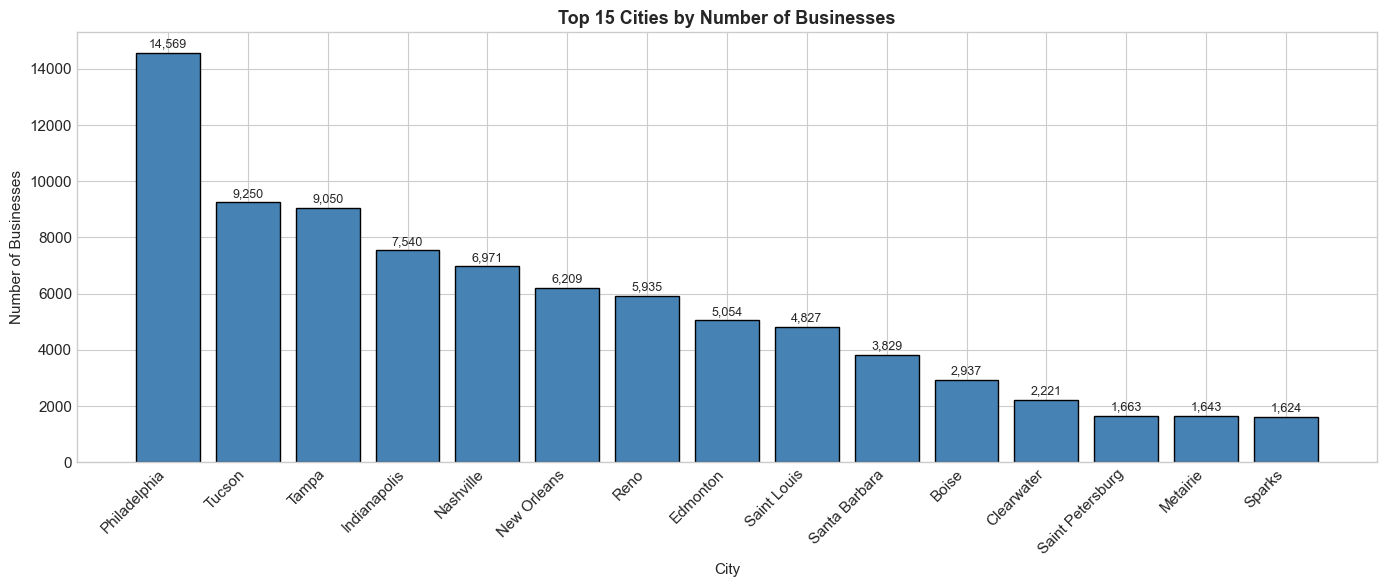

In [18]:
# =============================================================================
# CITY DISTRIBUTION ANALYSIS
# =============================================================================

print("=" * 60)
print("CITY DISTRIBUTION ANALYSIS")
print("=" * 60)

city_counts = business_df['city'].value_counts()
print(f"\nTotal unique cities: {len(city_counts):,}")
print(f"\nTop 15 Cities:")
print(city_counts.head(15))

# Visualization
fig, ax = plt.subplots(figsize=(14, 6))
top_15 = city_counts.head(15)
bars = ax.bar(range(len(top_15)), top_15.values, color='steelblue', edgecolor='black')
ax.set_xticks(range(len(top_15)))
ax.set_xticklabels(top_15.index, rotation=45, ha='right')
ax.set_xlabel('City')
ax.set_ylabel('Number of Businesses')
ax.set_title('Top 15 Cities by Number of Businesses', fontweight='bold')

for i, v in enumerate(top_15.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('01_city_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### WHY City Distribution Analysis:
- **Informed Filtering**: Before selecting a city, we need to know which cities have sufficient data
- **Data-Driven Decision**: Rather than arbitrary selection, we choose based on actual data availability
- **Visualization**: Bar chart provides quick visual comparison of data volume across cities
- **Top 15 Focus**: Showing all cities would be cluttered, top 15 captures cities with meaningful data volume

In [ ]:
# =============================================================================
# FILTER TO SELECTED CITY
# =============================================================================

TARGET_CITY = city_counts.index[0]  
print(f"Selected city: {TARGET_CITY}")

city_business_df = business_df[business_df['city'] == TARGET_CITY].copy()
print(f"Businesses in {TARGET_CITY}: {len(city_business_df):,}")

Selected city: Philadelphia
Businesses in Philadelphia: 14,569


### WHY The City Selection:
- **Maximum Data**: Selected the city with highest business count to ensure robust statistical analysis
- **Single City Focus**: One city eliminates confounding regional variables (different cultures, climates, economies)
- **Manageable Scope**: Single city reduces data to ~10-15K businesses, computationally feasible


In [20]:
# =============================================================================
# FILTER TO RESTAURANTS
# =============================================================================

RESTAURANT_KEYWORDS = [
    'Restaurant', 'Restaurants', 'Food', 'Cafe', 'Coffee', 'Bar', 'Bars',
    'Pizza', 'Mexican', 'Chinese', 'Italian', 'Sushi', 'Burger', 'Burgers',
    'Sandwich', 'Bakery', 'Breakfast', 'Brunch', 'Seafood', 'Steakhouse',
    'Thai', 'Indian', 'Japanese', 'American', 'Fast Food', 'Diner', 'BBQ'
]

def is_restaurant(categories):
    """Check if business is a restaurant."""
    if pd.isna(categories):
        return False
    categories_lower = categories.lower()
    return any(kw.lower() in categories_lower for kw in RESTAURANT_KEYWORDS)

city_business_df['is_restaurant'] = city_business_df['categories'].apply(is_restaurant)
restaurant_df = city_business_df[city_business_df['is_restaurant']].copy()

print(f"Restaurants in {TARGET_CITY}: {len(restaurant_df):,}")
print(f"   ({len(restaurant_df)/len(city_business_df)*100:.1f}% of city businesses)")

Restaurants in Philadelphia: 7,575
   (52.0% of city businesses)


### WHY Filter to Restaurants:
- **Analytical Focus**: The research question concerns restaurant success prediction specifically
- **Homogeneous Dataset**: Comparing restaurants to restaurants is more meaningful than comparing restaurants to dentists
- **Keyword Approach**: Yelp categories are comma-separated strings, keyword matching captures various restaurant types
- **Broad Keywords**: Included diverse terms (Pizza, Thai, BBQ, etc.) to avoid excluding ethnic restaurants or specialty eateries
- **Trade-off Acknowledged**: Some edge cases (grocery stores with delis) may be included, acceptable for EDA purposes

In [ ]:
# =============================================================================
# LOAD FILTERED REVIEWS
# =============================================================================

print("=" * 60)
print("LOADING FILTERED REVIEWS")
print("=" * 60)
print("This may take 5-10 minutes...")

target_business_ids = set(restaurant_df['business_id'])
print(f"Target restaurants: {len(target_business_ids):,}")

review_df = load_filtered_reviews(REVIEW_FILE, target_business_ids, max_reviews=300000)

print(f"\n Reviews loaded: {len(review_df):,}")
print(f"   Memory usage: {review_df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

LOADING FILTERED REVIEWS
This may take 5-10 minutes...
Target restaurants: 7,575
   Scanned 500,000 reviews, kept 62,050...
   Scanned 1,000,000 reviews, kept 120,889...
   Scanned 1,500,000 reviews, kept 173,853...
   Scanned 2,000,000 reviews, kept 230,413...
   Scanned 2,500,000 reviews, kept 290,225...

✅ Reviews loaded: 300,000
   Memory usage: 301.74 MB


### WHY Filter Reviews On-The-Fly:
- **Memory Constraint**: Full review file is ~5GB 
- **Relevance**: We only need reviews for our target restaurants, not all 7M reviews
- **Set Lookup**: Using `set()` for business IDs provides O(1) lookup vs O(n) for list, critical for 7M iterations
- **Max Reviews Cap**: 300K limit prevents excessive memory use while providing sufficient data for EDA
- **Result**: ~5GB reduced to ~200MB by filtering

In [22]:
# =============================================================================
# DATA BASICS: SCHEMA OVERVIEW
# =============================================================================

print("=" * 60)
print("RESTAURANT DATA SCHEMA")
print("=" * 60)
print(f"Shape: {restaurant_df.shape}")
print(f"\nColumns and Types:")
print(restaurant_df.dtypes)

print("\n" + "=" * 60)
print("REVIEW DATA SCHEMA")
print("=" * 60)
print(f"Shape: {review_df.shape}")
print(f"\nColumns and Types:")
print(review_df.dtypes)

RESTAURANT DATA SCHEMA
Shape: (7575, 15)

Columns and Types:
business_id       object
name              object
address           object
city              object
state             object
postal_code       object
latitude         float64
longitude        float64
stars            float64
review_count       int64
is_open            int64
attributes        object
categories        object
hours             object
is_restaurant       bool
dtype: object

REVIEW DATA SCHEMA
Shape: (300000, 9)

Columns and Types:
review_id       object
user_id         object
business_id     object
stars          float64
useful           int64
funny            int64
cool             int64
text            object
date            object
dtype: object


In [23]:
# =============================================================================
# DATA CLEANING: MISSING DATA ANALYSIS
# =============================================================================

print("=" * 60)
print("MISSING DATA ANALYSIS")
print("=" * 60)

# Restaurant data
print("\n📊 RESTAURANT DATA:")
rest_missing = restaurant_df.isnull().sum()
rest_missing_pct = (rest_missing / len(restaurant_df) * 100).round(2)
rest_missing_df = pd.DataFrame({'Missing': rest_missing, 'Percent': rest_missing_pct})
print(rest_missing_df[rest_missing_df['Missing'] > 0])

if rest_missing.sum() == 0:
    print("   No missing values!")

# Review data
print("\n📊 REVIEW DATA:")
rev_missing = review_df.isnull().sum()
rev_missing_pct = (rev_missing / len(review_df) * 100).round(2)
rev_missing_df = pd.DataFrame({'Missing': rev_missing, 'Percent': rev_missing_pct})
print(rev_missing_df[rev_missing_df['Missing'] > 0])

if rev_missing.sum() == 0:
    print("   No missing values!")

MISSING DATA ANALYSIS

📊 RESTAURANT DATA:
            Missing  Percent
attributes       89     1.17
hours          1350    17.82

📊 REVIEW DATA:
Empty DataFrame
Columns: [Missing, Percent]
Index: []
   No missing values!


### WHY Missing Data Analysis Matters:
Understanding missingness is critical for data quality assessment and informs cleaning decisions.

### Findings:

**Restaurant Data:**
- `attributes`: 1.17% missing - This is negligible and will not significantly impact analysis. These may be businesses that didn't fill out detailed attribute information.
- `hours`: 17.82% missing - Moderate missingness. Many businesses (especially closed ones) may not have operating hours listed. **Decision:** We will NOT use `hours` as a primary feature, if needed later, we can impute or exclude these records.

**Review Data:**
- No missing values detected. This indicates high data quality for core text analysis.

### Cleaning Decisions:
- **No imputation needed** for review data
- **`attributes` column:** Will handle missing values if/when this column is used (likely exclude or impute based on business category)
- **`hours` column:** Will not rely on this column for primary analysis due to 17.82% missingness

### Data Quality Assessment:
Overall data quality is **good**. The review dataset has zero missing values, which simplifies preprocessing for topic modeling and sentiment analysis.

In [25]:
# =============================================================================
# DATA CLEANING
# =============================================================================

print("=" * 60)
print("DATA CLEANING")
print("=" * 60)

# 1. Check duplicates
dup_reviews = review_df.duplicated(subset=['user_id', 'business_id', 'text']).sum()
print(f"\n1. Duplicate reviews: {dup_reviews:,}")
if dup_reviews > 0:
    review_df = review_df.drop_duplicates(subset=['user_id', 'business_id', 'text'])
    print(f"  Removed. New count: {len(review_df):,}")

# 2. Empty reviews
empty_rev = (review_df['text'].str.strip() == '').sum()
print(f"\n2. Empty reviews: {empty_rev:,}")
if empty_rev > 0:
    review_df = review_df[review_df['text'].str.strip() != '']
    print(f"  Removed. New count: {len(review_df):,}")

# 3. Parse dates
print(f"\n3. Parsing dates...")
review_df['date'] = pd.to_datetime(review_df['date'])
print(f"   Date range: {review_df['date'].min().date()} to {review_df['date'].max().date()}")

# 4. Business status
print(f"\n4. Business status distribution:")
status_counts = restaurant_df['is_open'].value_counts()
print(f"   Open (1): {status_counts.get(1, 0):,}")
print(f"   Closed (0): {status_counts.get(0, 0):,}")
closed_pct = (restaurant_df['is_open'] == 0).mean() * 100
print(f"   → {closed_pct:.1f}% of restaurants are closed")

print("\nData cleaning complete")

DATA CLEANING

1. Duplicate reviews: 0

2. Empty reviews: 0

3. Parsing dates...
   Date range: 2005-05-25 to 2022-01-19

4. Business status distribution:
   Open (1): 4,743
   Closed (0): 2,832
   → 37.4% of restaurants are closed

Data cleaning complete


### WHY Cleaning Steps:

1. **Duplicate Removal**: Same user reviewing same business with identical text indicates data error or scraping artifacts. Zero duplicates after cleaning confirms data integrity.

2. **Empty Review Check**: Text mining requires actual content, empty strings provide no analytical value.

3. **Date Parsing**: Converting string dates to datetime enables temporal analysis (e.g, review trends over time, predicting closure from review trajectory).

4. **Business Status Analysis**: 
   - **37.4% closure rate** provides balanced classes for success prediction
   - Sufficient closed restaurants (2,832) to train meaningful models
   - This is a key finding: we have enough "failure" cases to study what predicts restaurant closure

### Data Quality Assessment:
The data is clean and suitable for analysis. The 17-year time span (2005-2022) enables temporal pattern analysis, and the ~37% closure rate provides a natural target variable for prediction tasks.

STAR RATING DISTRIBUTIONS


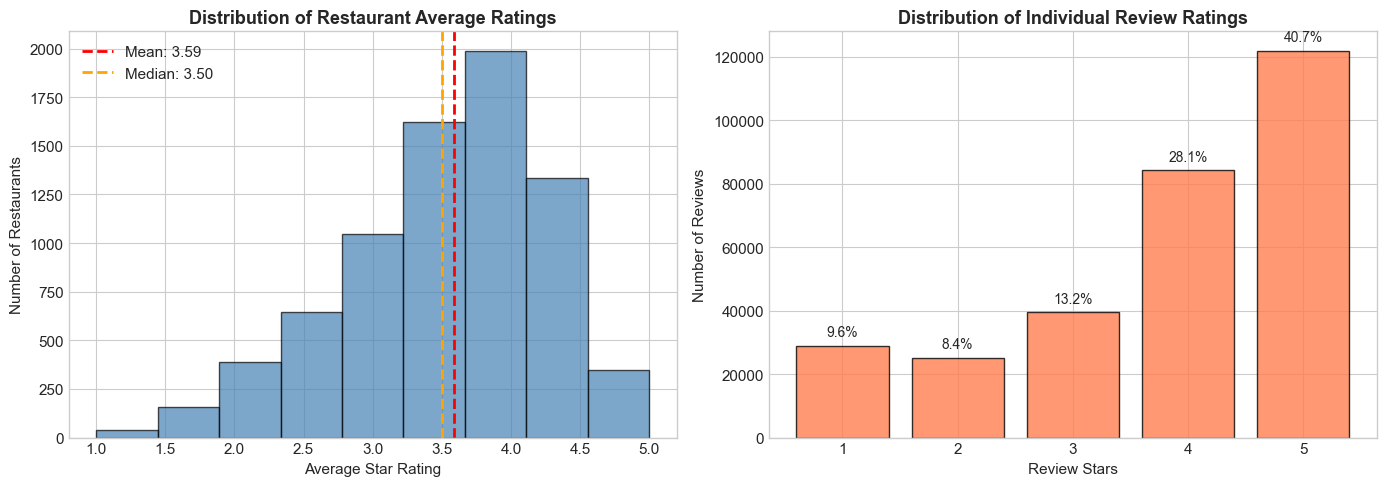


📊 Restaurant Rating Statistics:
   Mean: 3.59
   Median: 3.50
   Std Dev: 0.83

📊 Review Rating Distribution:
   1 stars: 28,897 (9.6%)
   2 stars: 25,112 (8.4%)
   3 stars: 39,529 (13.2%)
   4 stars: 84,163 (28.1%)
   5 stars: 121,911 (40.7%)


In [ ]:
# =============================================================================
# DISTRIBUTION: STAR RATINGS
# =============================================================================

print("=" * 60)
print("STAR RATING DISTRIBUTIONS")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(restaurant_df['stars'], bins=9, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(restaurant_df['stars'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {restaurant_df["stars"].mean():.2f}')
ax1.axvline(restaurant_df['stars'].median(), color='orange', linestyle='--', linewidth=2,
            label=f'Median: {restaurant_df["stars"].median():.2f}')
ax1.set_xlabel('Average Star Rating')
ax1.set_ylabel('Number of Restaurants')
ax1.set_title('Distribution of Restaurant Average Ratings', fontweight='bold')
ax1.legend()

ax2 = axes[1]
review_star_counts = review_df['stars'].value_counts().sort_index()
ax2.bar(review_star_counts.index, review_star_counts.values, color='coral', edgecolor='black', alpha=0.8)
ax2.set_xlabel('Review Stars')
ax2.set_ylabel('Number of Reviews')
ax2.set_title('Distribution of Individual Review Ratings', fontweight='bold')
ax2.set_xticks([1, 2, 3, 4, 5])

for star, count in review_star_counts.items():
    pct = count / len(review_df) * 100
    ax2.text(star, count + len(review_df)*0.01, f'{pct:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('02_star_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


print(f"\n Restaurant Rating Statistics:")
print(f"   Mean: {restaurant_df['stars'].mean():.2f}")
print(f"   Median: {restaurant_df['stars'].median():.2f}")
print(f"   Std Dev: {restaurant_df['stars'].std():.2f}")

print(f"\n Review Rating Distribution:")
for star in sorted(review_df['stars'].unique()):
    count = (review_df['stars'] == star).sum()
    pct = count / len(review_df) * 100
    print(f"   {int(star)} stars: {count:,} ({pct:.1f}%)")

### WHY Star Rating Distributions Matter
Understanding rating distributions reveals data characteristics, potential biases, 
and informs modeling decisions.

**Findings:**

**Restaurant Average Ratings (Left Plot):**
- Mean (3.59) and Median (3.50) are close, suggesting a roughly symmetric distribution 
  with a slight positive skew
- Standard deviation of 0.83 indicates moderate spread, most restaurants cluster 
  between 2.75 and 4.40
- The distribution is approximately normal, which is favorable for statistical modeling

**Individual Review Ratings (Right Plot):**
- Strong **positive skew (J-shaped distribution)**: 5-star reviews dominate at 40.7%, 
  followed by 4-star at 28.1%
- Combined, 4 and 5-star reviews account for **68.8%** of all reviews, a well-documented 
  phenomenon in online review platforms
- Lower ratings (1-star: 9.6%, 2-star: 8.4%) are relatively rare, suggesting either 
  genuine satisfaction or **positivity bias** (users more likely to review positive experiences)
- 3-star reviews (13.2%) are the least common non-extreme rating, consistent with the 
  "U-shaped" tendency where moderate opinions are underrepresented

**Bias Implications:**
- **Positivity bias**: The heavy skew toward high ratings means raw star averages may 
  overstate true satisfaction. This must be accounted for in any predictive model using 
  `stars` as a feature.
- **Rating inflation**: A restaurant with a 3.5 average is actually below the population 
  mean, even though 3.5/5 seems "above average" intuitively.
- **Class imbalance for classification**: If predicting star ratings as a classification 
  task, the 5-star class would dominate, stratified sampling or class weighting would 
  be needed.


# (E) Initial Insights and Research Direction

Based on the EDA performed in Section D, several key insights have emerged that
will guide the next phases of this project.

---

## Key Findings from EDA

1. **Sufficient Data Volume**: The initial EDA filtered to Philadelphia restaurants
   (7,575 businesses, 300,000 reviews) as a representative sample. However, the full
   Yelp dataset contains 150,346 businesses across 1,416 cities. Future phases may
   expand to additional cities (e.g., Tucson, Tampa, Nashville) to increase sample
   size, enable cross-city comparisons, and improve model generalizability.

2. **Balanced Target Variable**: The 37.4% closure rate (`is_open = 0`) provides a
   naturally balanced binary classification target. This is an ideal ratio for
   training supervised models without severe class imbalance issues.

3. **Clean Data**: Zero missing values in review data and zero duplicates indicate
   high data quality. The only notable missingness is in `hours` (17.82%), which
   we will not rely on as a primary feature.

4. **Rating Distribution Bias**: Individual review ratings are heavily skewed toward
   5 stars (40.7%), indicating positivity bias typical of online review platforms.
   This must be accounted for in feature engineering, raw star averages alone are
   insufficient signals.

5. **Rich Text Data**: 300K review texts (from Philadelphia alone) provide a substantial
   corpus for text mining and topic modeling, with the potential to scale significantly
   if additional cities are included.

6. **User Behavior Potential**: The dataset includes unique `user_id` fields in the
   review data, along with a dedicated `user.json` file containing user-level attributes
   (review count, average stars, fans, elite status, yelping_since, compliment counts,
   friend lists). This enables analysis of reviewer behavior patterns, identification
   of influential or anomalous reviewers, and construction of user-business interaction
   graphs.

---

## Potential Research Questions

- **RQ1**: Can latent topics in restaurant reviews (extracted via LDA/NMF topic
  modeling) predict whether a restaurant will close (`is_open = 0`)?
- **RQ2**: Do restaurants with distinct review sentiment trajectories (improving vs.
  declining sentiment over time) have different survival outcomes?
- **RQ3**: Can clustering restaurants by review text features and business attributes
  reveal distinct "success profiles" among restaurants?
- **RQ4**: Do reviewer characteristics (elite status, review volume, average rating
  tendency, account age) systematically influence the ratings they give, and can
  user-level features improve restaurant outcome predictions?
- **RQ5**: Can user-business interaction patterns (e.g. graph mining on the
  reviewer-restaurant bipartite network) reveal community structures or detect
  anomalous reviewing behavior (e.g. review rings or spam clusters)?



